In [1]:
import numpy as np
import scipy as sp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import scienceplots

from matplotlib.font_manager import FontProperties

from resonator_coupling_circuit_projected import RCCircuitCoup

from tqdm import tqdm

plt.style.use('science')

h = 6.62607015e-34
hbar = 1.054571817e-34
e_charge = 1.60217663e-19

The "RCCircuitCoup" module has been imported. This module allows to calculate the parallel and perpendicular coupling in a circuit of a flux qubit (probe) coupled to a resonator coupled to a transmon qubit. The method uses an Hamiltonian term projected into the probe qubit subspace.


# Spectrum and qubit gap

In [17]:
systemProj = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], ng=0.25, flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5)

In [19]:
# spectrum varying flux, ng=0
evals_list = []
fluxes = np.linspace(0,1,201)

system = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)
for flux in tqdm(fluxes):
    system.flux = flux
    evals, evecs = system.diagonalise_p(update=True)
    #evals_list.append(np.diff(evals[:5]))
    #evals_list.append(evals[:5]-evals[0])
    evals_list.append(evals[:5])

evals = np.asarray(evals_list)

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:31<00:00,  6.35it/s]


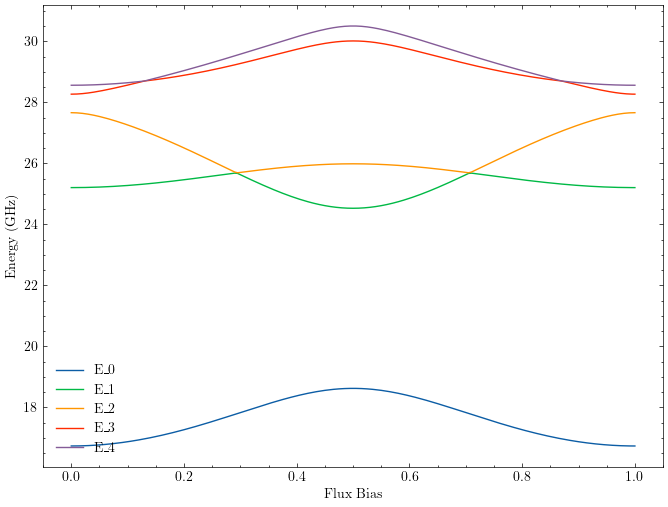

In [20]:
plt.figure(figsize=(8,6))
plt.plot(fluxes, (evals * 1e-9) / h)
plt.xlabel('Flux Bias')
plt.ylabel('Energy (GHz)')
plt.legend([f'E_{n} ' for n in range(len(evals))])
plt.show()

In [21]:
# spectrum varying flux, ng=0.5
evals_list = []
fluxes = np.linspace(0,1,201)

system2 = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0.5)
for flux in tqdm(fluxes):
    system2.flux = flux
    evals, evecs = system2.diagonalise_p(update=True)
    #evals_list.append(np.diff(evals[:5]))
    #evals_list.append(evals[:5]-evals[0])
    evals_list.append(evals[:5])

evals = np.asarray(evals_list)

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:35<00:00,  5.74it/s]


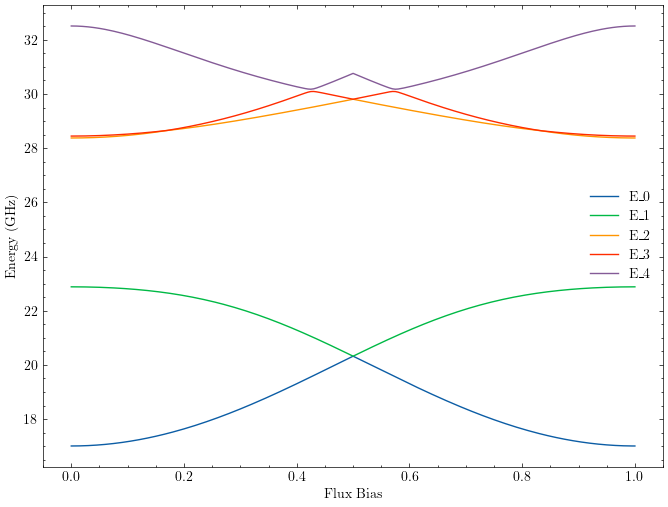

In [9]:
plt.figure(figsize=(8,6))
plt.plot(fluxes, (evals * 1e-9) / h)
plt.xlabel('Flux Bias')
plt.ylabel('Energy (GHz)')
plt.legend([f'E_{n} ' for n in range(len(evals))])
plt.show()

In [22]:
# qubit gap varying offset charge and asymmetry
fig_17a_ngs_p = np.linspace(-1, 1, 201)
alphas = [0.2, 0.4, 0.6]

system = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17a_results_p = {}

for alpha in alphas:
    fig_17a_results_p[alpha] = []
    system.alphas = [alpha, alpha, 1, 1]

    for ng in tqdm(fig_17a_ngs_p):
        system.ng = ng

        evals, evecs = system.diagonalise_p(update=True)
        evals = np.real(evals) * 1e-9 / h

        delta = evals[1] - evals[0]

        fig_17a_results_p[alpha].append(delta)


100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:34<00:00,  5.90it/s]


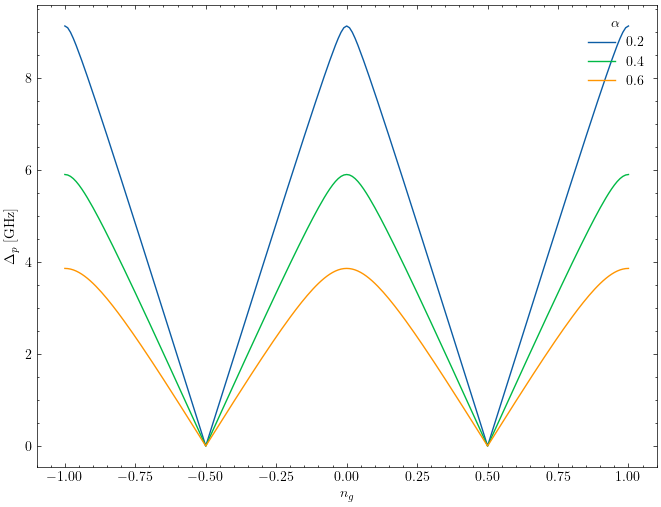

In [23]:
plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

#plt.title('Probe qubit energy gap', **font)
plt.xlabel('$n_g$')
plt.ylabel('$\\Delta_p$ [GHz]')

for alpha in fig_17a_results_p.keys():
    plt.plot(fig_17a_ngs_p, fig_17a_results_p[alpha], label=round(alpha,2))

legend = plt.legend(title='$\\alpha$', loc= 'upper right')

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()

In [14]:
fig_17b_ngs_p = np.linspace(-1, 1, 201)
# fig_17b_Ccs_p = np.linspace(0, 10e-15, 12)
fig_17b_Ccps_p = [0e-15, 5e-15, 10e-15]

system = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17b_results_p = {}

for CcpV in fig_17b_Ccps_p:
    fig_17b_results_p[CcpV] = []
    system.Ccp = CcpV

    for ng in tqdm(fig_17b_ngs_p):
        system.ng = ng

        delta = system.calc_probe_freq(update=True) * 1e-9 / h

        fig_17b_results_p[CcpV].append(delta)

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:46<00:00,  4.37it/s]


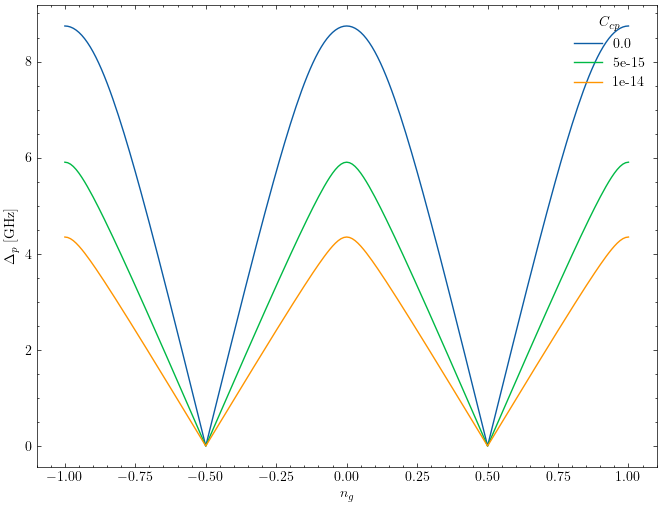

In [16]:

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

#plt.title('Qubit energy gap (calculated from eigenenergies)')
plt.xlabel('$n_g$')
plt.ylabel('$\\Delta_p$ [GHz]')

plt.rc('font')

for Ccp in fig_17b_results_p.keys():
    plt.plot(fig_17b_ngs_p, fig_17b_results_p[Ccp], label=Ccp)

legend =plt.legend(title='$C_{cp}$', loc= 'upper right')

plt.show()

A relatively large qubit gap, along with easier tunability via asymmetry and coupling capacitance.

# Longitudinal coupling strength

coupling vs offset charge and capacitance

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:19<00:00, 10.23it/s]


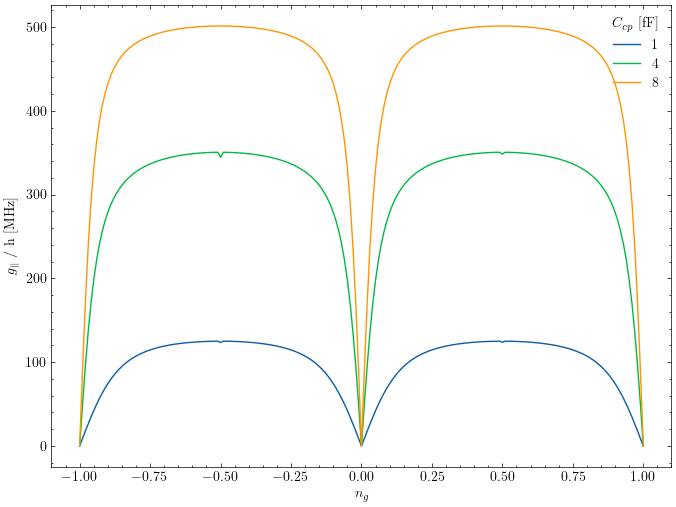

In [28]:
# longitudinal coupling strength, varying offset charge and coupling capacitance
# josephson energy of the probe Ejp=10e9

fig_17c_ngs_p = np.linspace(-1, 1, 201)
# fig_17c_Ccps_p = [val * 1e-15 for val in range(1,9)]
fig_17c_Ccps_p = [1e-15, 4e-15, 8e-15]

system = RCCircuitCoup(Ejp=10e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17c_g_parr_results = {}
fig_17c_g_perp_results = {}

for CcpV in fig_17c_Ccps_p:
    fig_17c_g_parr_results[CcpV] = []
    fig_17c_g_perp_results[CcpV] = []
    system.Ccp = CcpV

    for ng in tqdm(fig_17c_ngs_p):
        system.ng = ng

        system.init_probe_states(update=True)

        g_parr = system.calc_g_parr() * 1e-6 / h
        g_perp = system.calc_g_perp() * 1e-6 / h

        fig_17c_g_parr_results[CcpV].append(g_parr)
        fig_17c_g_perp_results[CcpV].append(g_perp)

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

plt.xlabel('$n_g$')
plt.ylabel('$g_\\parallel$ / h [MHz]',)

plt.rc('font')

for Ccp in fig_17c_g_parr_results.keys():
    plt.plot(fig_17c_ngs_p, np.abs(fig_17c_g_parr_results[Ccp]), label=round(Ccp * 1e15))

legend = plt.legend(title='$C_{cp}$ [fF]', loc= 'upper right')

plt.show()

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:17<00:00, 11.50it/s]


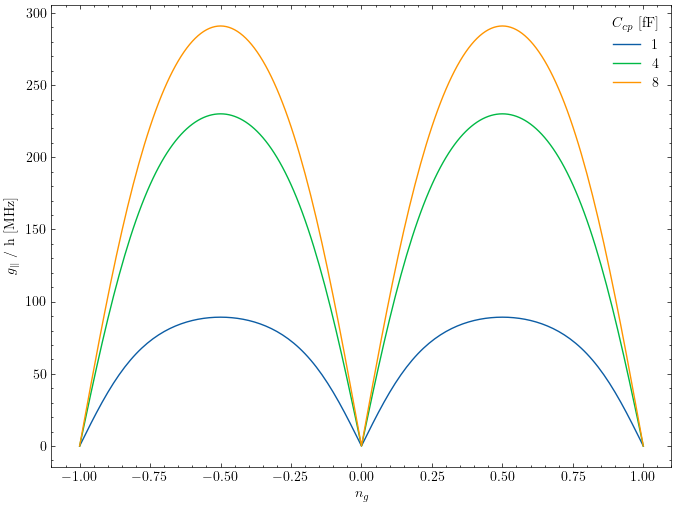

In [29]:
# longitudinal coupling strength, varying offset charge and coupling capacitance
# josephson energy of the probe Ejp=100e9

fig_17c_ngs_p = np.linspace(-1, 1, 201)
# fig_17c_Ccps_p = [val * 1e-15 for val in range(1,9)]
fig_17c_Ccps_p = [1e-15, 4e-15, 8e-15]

system = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17c_g_parr_results = {}
fig_17c_g_perp_results = {}

for CcpV in fig_17c_Ccps_p:
    fig_17c_g_parr_results[CcpV] = []
    fig_17c_g_perp_results[CcpV] = []
    system.Ccp = CcpV

    for ng in tqdm(fig_17c_ngs_p):
        system.ng = ng

        system.init_probe_states(update=True)

        g_parr = system.calc_g_parr() * 1e-6 / h
        g_perp = system.calc_g_perp() * 1e-6 / h

        fig_17c_g_parr_results[CcpV].append(g_parr)
        fig_17c_g_perp_results[CcpV].append(g_perp)

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

plt.xlabel('$n_g$')
plt.ylabel('$g_\\parallel$ / h [MHz]',)

plt.rc('font')

for Ccp in fig_17c_g_parr_results.keys():
    plt.plot(fig_17c_ngs_p, np.abs(fig_17c_g_parr_results[Ccp]), label=round(Ccp * 1e15))

legend = plt.legend(title='$C_{cp}$ [fF]', loc= 'upper right')

plt.show()

In order to produce the expected results, the probe must satisfy $E_{Jp}\gg E_{Cp}$.

Overall larger qubit gap and coupling strength obtained.

coupling vs asymemtry

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [01:03<00:00,  3.18it/s]


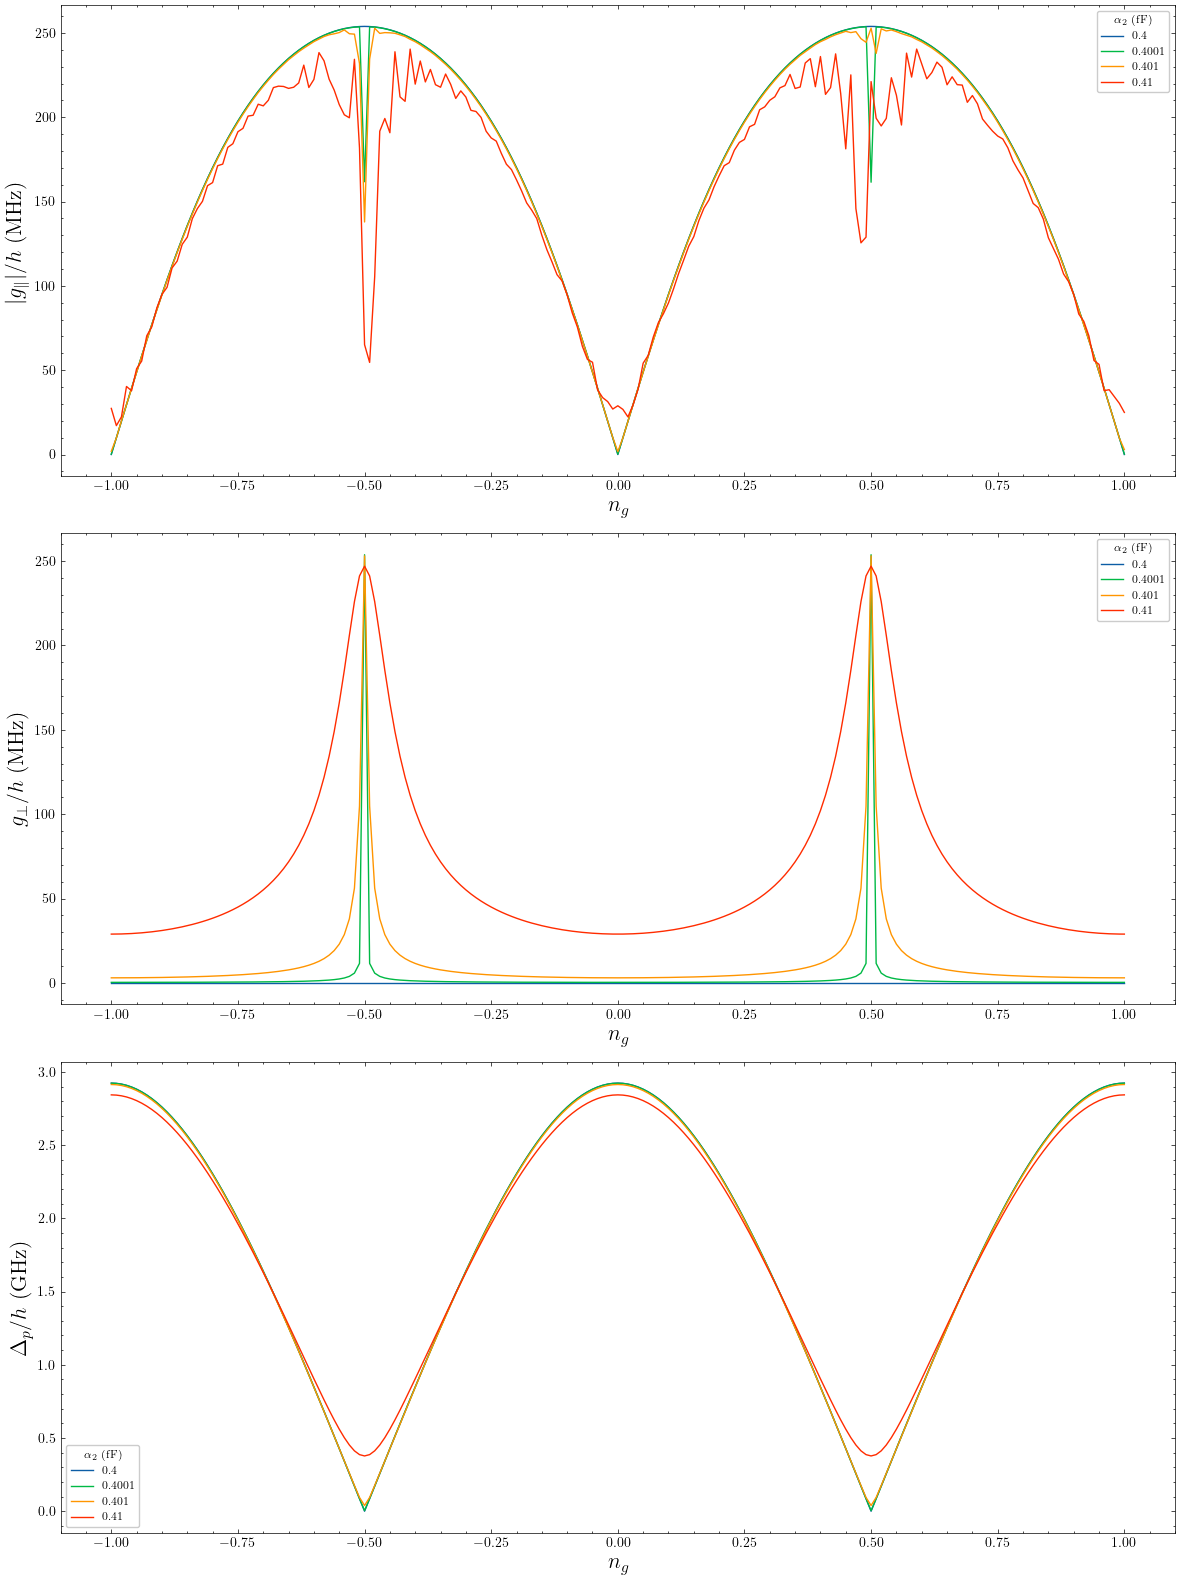

In [31]:
import pickle

fig_17c_ngs_p = np.linspace(-1, 1, 201)
alpha2s = [0.4,0.4001,0.401,0.41]

system = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

alpha_disp_results = {}

for alpha2 in alpha2s:
    if alpha2 in alpha_disp_results.keys():
        continue

    alpha_disp_results[alpha2] = {
        'ng': [],
        'g_parr': [],
        'g_perp': [],
        'probe_freq': [],
        #'cavity_freq': [],
        #'target_freq': []
    }

    system.alphas = [0.4, alpha2, 1, 1] 
    for ng in tqdm(fig_17c_ngs_p):
        system.ng = ng

        g_parr = system.calc_g_parr(update=True) * 1e-6 / h
        g_perp = system.calc_g_perp(update=True) * 1e-6 / h
        probe_freq = system.calc_probe_freq(update=True) * 1e-9 / h

        alpha_disp_results[alpha2]['ng'].append(ng)
        alpha_disp_results[alpha2]['g_parr'].append(g_parr)
        alpha_disp_results[alpha2]['g_perp'].append(g_perp)
        alpha_disp_results[alpha2]['probe_freq'].append(probe_freq)

obserables = [
    {'name': 'g_parr', 'ylabel': '$|g_\\parallel| / h$ (MHz)'},
    {'name': 'g_perp', 'ylabel': '$g_\\perp / h$ (MHz)'},
    #{'name': 'cavity_freq', 'ylabel': '$omega / h$ (GHz)', 'y_lim': [0, 8]},
    {'name': 'probe_freq', 'ylabel': '$\\Delta_p / h$ (GHz)'},
    #{'name': 'target_freq', 'ylabel': '$\\Delta_t / h$ (GHz)', 'y_lim': [0, 8]}
]

fig, ax = plt.subplots(figsize=(12, 16), nrows=3, ncols=1)
ax = ax.flatten()
for idx, obs in enumerate(obserables):
    pparam = dict(xlabel='$n_g$', ylabel=obs['ylabel'])

    with plt.style.context(['ieee', 'grid']):
        for alpha in alpha_disp_results.keys():
            ax[idx].plot(alpha_disp_results[alpha]['ng'], np.abs(alpha_disp_results[alpha][obs['name']]), label=alpha)
        
        if 'y_lim' in obs.keys():
            ax[idx].set_ylim(obs['y_lim'])
        
        ax[idx].legend(title='$\\alpha_2$ (fF)')
        ax[idx].set(**pparam)
        ax[idx].xaxis.label.set_size(16)
        ax[idx].yaxis.label.set_size(16)

plt.tight_layout()
plt.show()


Highly sensitive to asymmetry, where even small variations in asymmetry can lead to significant changes in the coupling strength.